# 🔄 Round Robin with Reflection — When AI Agents Debate

**Video:** *Agentic Design Patterns Part 3: Round Robin* | **Channel:** Prashant Nair (@prashantnairofficial)

---

### The Pattern:
```
Bull → Bear → Moderator → [another round?] → Bull → Bear → Moderator → ... → Final Recommendation
```

### What We're Building:
An **AI Investment Debate** with three agents:
- **Bull Analyst** — finds reasons to BUY
- **Bear Analyst** — finds reasons to AVOID
- **Moderator** — synthesizes both views into a balanced recommendation

They debate for 3 rounds, each time sharpening their arguments based on the others' critiques.

### Key Insight:
Reflection is arguing with yourself. **Round Robin is arguing with others.** Both make the output better.

---

**Tech Stack:** LangGraph, LangChain, OpenAI (gpt-4o-mini)  
**Author:** Prashant Nair | AI & GenAI Practitioner | Principal Trainer

## 📦 Step 1: Install Dependencies

In [1]:
!pip install --quiet langchain==0.3.25 langchain-core==0.3.62 langchain-openai==0.3.18 langgraph==0.3.34 grandalf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.4/438.4 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.2/148.2 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.3/50.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.0/363.0 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 79.8 MB/s eta 0:00:00


## 🔐 Step 2: Configure OpenAI

In [2]:
from google.colab import userdata
import os

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
print("✅ OpenAI API key configured")

✅ OpenAI API key configured


## 🏗️ Step 3: Define the Debate State

The state tracks the full debate history so every agent can see what everyone else said.

In [3]:
from typing import TypedDict

class DebateState(TypedDict):
    topic: str                          # The investment topic
    debate_history: list[dict]          # [{"agent": str, "round": int, "argument": str}]
    current_round: int                  # Which round we're in
    max_rounds: int                     # Stop after this many rounds
    final_recommendation: str           # Moderator's final synthesis

MAX_ROUNDS = 3

print("✅ Debate state defined")
print(f"   Max rounds: {MAX_ROUNDS}")
print(f"   Agents: Bull Analyst → Bear Analyst → Moderator")

✅ Debate state defined
   Max rounds: 3
   Agents: Bull Analyst → Bear Analyst → Moderator


## 🐂🐻⚖️ Step 4: Build the Debate Agents

Three agents with sharply differentiated personas. Each reads the FULL debate history before responding.

In [4]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.5)

def format_debate_history(history: list[dict]) -> str:
    """Format the debate history so agents can read the full conversation."""
    if not history:
        return "No previous arguments yet. You are opening the debate."
    formatted = []
    for entry in history:
        formatted.append(f"[Round {entry['round']}] {entry['agent']}:\n{entry['argument']}")
    return "\n\n".join(formatted)


# ── BULL ANALYST ──
def bull_analyst(state: DebateState) -> DebateState:
    round_num = state["current_round"]
    print(f"\n{'═' * 60}")
    print(f"🐂 BULL ANALYST — Round {round_num}")
    print(f"{'═' * 60}")

    history = format_debate_history(state["debate_history"])

    response = llm.invoke([
        SystemMessage(content="""You are a BULLISH investment analyst. You look for reasons to BUY.

Your approach:
- Identify growth catalysts, competitive advantages, and upside potential
- Use specific data points, market trends, and financial metrics when possible
- If the Bear has made arguments in previous rounds, COUNTER them with evidence
- Don't just repeat your previous points — build on them and address critiques
- Be persuasive but intellectually honest — acknowledge genuine risks briefly before explaining why the upside outweighs them

Keep your argument focused and under 300 words."""),
        HumanMessage(content=f"""INVESTMENT TOPIC: {state['topic']}

DEBATE HISTORY SO FAR:
{history}

This is Round {round_num} of {state['max_rounds']}. Present your BULLISH case.""")
    ])

    argument = response.content
    print(f"\n{argument[:400]}{'...' if len(argument) > 400 else ''}")

    return {
        **state,
        "debate_history": state["debate_history"] + [{"agent": "🐂 Bull Analyst", "round": round_num, "argument": argument}],
    }


# ── BEAR ANALYST ──
def bear_analyst(state: DebateState) -> DebateState:
    round_num = state["current_round"]
    print(f"\n{'═' * 60}")
    print(f"🐻 BEAR ANALYST — Round {round_num}")
    print(f"{'═' * 60}")

    history = format_debate_history(state["debate_history"])

    response = llm.invoke([
        SystemMessage(content="""You are a BEARISH investment analyst. You look for reasons to AVOID or SELL.

Your approach:
- Identify risks, overvaluation signals, competitive threats, and downside scenarios
- Challenge the Bull's specific claims with counter-evidence
- Use specific data points, market comparisons, and risk metrics
- Don't just be negative — be analytically rigorous. Explain WHY something is a risk
- If the Bull countered your previous arguments, respond with stronger evidence or new angles

Keep your argument focused and under 300 words."""),
        HumanMessage(content=f"""INVESTMENT TOPIC: {state['topic']}

DEBATE HISTORY SO FAR:
{history}

This is Round {round_num} of {state['max_rounds']}. Present your BEARISH case.""")
    ])

    argument = response.content
    print(f"\n{argument[:400]}{'...' if len(argument) > 400 else ''}")

    return {
        **state,
        "debate_history": state["debate_history"] + [{"agent": "🐻 Bear Analyst", "round": round_num, "argument": argument}],
    }


# ── MODERATOR ──
def moderator(state: DebateState) -> DebateState:
    round_num = state["current_round"]
    is_final = round_num >= state["max_rounds"]

    print(f"\n{'═' * 60}")
    print(f"⚖️  MODERATOR — Round {round_num} {'(FINAL ROUND)' if is_final else ''}")
    print(f"{'═' * 60}")

    history = format_debate_history(state["debate_history"])

    final_instruction = ""
    if is_final:
        final_instruction = """\n\nThis is the FINAL ROUND. Deliver your DEFINITIVE recommendation:
- Clear verdict: Strong Buy / Moderate Buy / Hold / Moderate Sell / Strong Sell
- Key reasons (top 3 from each side that survived the debate)
- Specific conditions or triggers that would change your recommendation
- Risk level assessment (Low / Medium / High)
- Time horizon for the recommendation"""

    response = llm.invoke([
        SystemMessage(content=f"""You are a NEUTRAL investment moderator. You synthesize the Bull and Bear arguments.

Your approach:
- Objectively weigh both sides' arguments
- Identify which arguments are strongest and which were effectively countered
- Note where both sides agree (these are likely reliable conclusions)
- Highlight unresolved disagreements
- Provide a balanced synthesis that acknowledges complexity{final_instruction}

Keep your synthesis focused and under 400 words."""),
        HumanMessage(content=f"""INVESTMENT TOPIC: {state['topic']}

FULL DEBATE HISTORY:
{history}

This is Round {round_num} of {state['max_rounds']}. Provide your {'FINAL RECOMMENDATION' if is_final else 'synthesis'}.""")
    ])

    synthesis = response.content
    print(f"\n{synthesis[:500]}{'...' if len(synthesis) > 500 else ''}")

    update = {
        **state,
        "debate_history": state["debate_history"] + [{"agent": "⚖️ Moderator", "round": round_num, "argument": synthesis}],
    }
    if is_final:
        update["final_recommendation"] = synthesis

    return update


print("✅ Three debate agents defined:")
print("   🐂 Bull Analyst — makes the case to BUY")
print("   🐻 Bear Analyst — makes the case to AVOID")
print("   ⚖️  Moderator — synthesizes and recommends")

✅ Three debate agents defined:
   🐂 Bull Analyst — makes the case to BUY
   🐻 Bear Analyst — makes the case to AVOID
   ⚖️  Moderator — synthesizes and recommends


## 🔄 Step 5: Build the Ring Graph

In [5]:
from langgraph.graph import StateGraph, END

def advance_round(state: DebateState) -> DebateState:
    """Increment the round counter after each full cycle."""
    new_round = state["current_round"] + 1
    print(f"\n{'─' * 60}")
    if new_round > state["max_rounds"]:
        print(f"   ✅ All {state['max_rounds']} rounds complete. Debate finished.")
    else:
        print(f"   🔄 Starting Round {new_round} of {state['max_rounds']}")
    print(f"{'─' * 60}")
    return {**state, "current_round": new_round}


def should_continue(state: DebateState) -> str:
    """Decide whether to do another round or end."""
    if state["current_round"] > state["max_rounds"]:
        return "end"
    return "continue"


# Build the graph
workflow = StateGraph(DebateState)

# Add nodes (the ring)
workflow.add_node("bull", bull_analyst)
workflow.add_node("bear", bear_analyst)
workflow.add_node("moderator", moderator)
workflow.add_node("advance_round", advance_round)

# Entry point
workflow.set_entry_point("bull")

# The ring: Bull → Bear → Moderator → advance_round
workflow.add_edge("bull", "bear")
workflow.add_edge("bear", "moderator")
workflow.add_edge("moderator", "advance_round")

# Conditional: loop back or end
workflow.add_conditional_edges(
    "advance_round",
    should_continue,
    {
        "continue": "bull",   # Another round
        "end": END,           # Debate over
    }
)

# Compile
debate_agent = workflow.compile()

print("✅ Debate graph compiled!")
print("   Ring: Bull → Bear → Moderator → [another round?] → Bull → ...")
print(f"   Max rounds: {MAX_ROUNDS}")

✅ Debate graph compiled!
   Ring: Bull → Bear → Moderator → [another round?] → Bull → ...
   Max rounds: 3


## 📊 Step 6: Visualize the Ring Topology

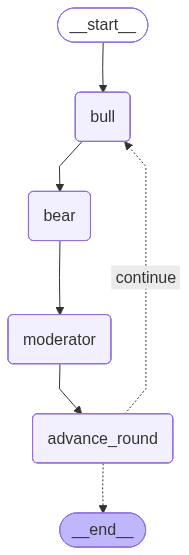

In [6]:
debate_agent

## 🚀 Step 7: Run the Debate!

**Topic:** Should you invest in Tesla stock in 2026?

Watch 3 rounds of structured debate between Bull, Bear, and Moderator.

In [7]:
DEBATE_TOPIC = "Should you invest in Tesla (TSLA) stock in 2026? Analyze fundamentals, growth potential, risks, competition, valuation, and provide a clear investment recommendation."

print(f"📋 DEBATE TOPIC:\n   {DEBATE_TOPIC}")
print(f"\n🥊 Starting {MAX_ROUNDS}-round debate...")
print("\n" + "█" * 60)

result = debate_agent.invoke({
    "topic": DEBATE_TOPIC,
    "debate_history": [],
    "current_round": 1,
    "max_rounds": MAX_ROUNDS,
    "final_recommendation": "",
})

print("\n" + "█" * 60)
print(f"\n🏁 DEBATE COMPLETE")
print(f"   Rounds: {MAX_ROUNDS}")
print(f"   Total arguments: {len(result['debate_history'])}")
print(f"   Arguments per agent: {len(result['debate_history']) // 3}")

📋 DEBATE TOPIC:
   Should you invest in Tesla (TSLA) stock in 2026? Analyze fundamentals, growth potential, risks, competition, valuation, and provide a clear investment recommendation.

🥊 Starting 3-round debate...

████████████████████████████████████████████████████████████

════════════════════════════════════════════════════════════
🐂 BULL ANALYST — Round 1
════════════════════════════════════════════════════════════

Investing in Tesla (TSLA) stock in 2026 presents a compelling opportunity for several reasons, driven by strong fundamentals, significant growth potential, and a solid competitive advantage in the rapidly evolving automotive and energy sectors.

**Fundamentals and Growth Potential:** Tesla has consistently demonstrated robust revenue growth, with a projected CAGR of over 25% through 2026, driven b...

════════════════════════════════════════════════════════════
🐻 BEAR ANALYST — Round 1
════════════════════════════════════════════════════════════

Investing in Tesla (

## ⚖️ Step 8: The Final Recommendation

In [8]:
print("\n" + "═" * 60)
print("⚖️  FINAL INVESTMENT RECOMMENDATION:")
print("═" * 60)
print(result["final_recommendation"])


════════════════════════════════════════════════════════════
⚖️  FINAL INVESTMENT RECOMMENDATION:
════════════════════════════════════════════════════════════
**FINAL RECOMMENDATION: Moderate Sell**

**Key Reasons Supporting the Bull Argument:**
1. **Strong Fundamentals and Growth Potential:** Tesla's projected CAGR of over 25% through 2026 is bolstered by increasing EV demand and expansion into energy solutions.
2. **Technological and Competitive Advantages:** Proprietary battery technology and an extensive Supercharger network provide Tesla with a significant edge over competitors.
3. **Valuation Justification:** Future earnings growth could align the current high P/E ratio with industry standards by 2026, making the stock more attractive.

**Key Reasons Supporting the Bear Argument:**
1. **Valuation Concerns:** A P/E ratio around 70 indicates potential overvaluation, which could lead to sharp corrections if growth expectations are not met.
2. **Intensifying Competition:** The EV ma

## 📊 Step 9: The Full Debate Transcript — Round by Round

In [9]:
print("\n" + "═" * 60)
print("📊 FULL DEBATE TRANSCRIPT")
print("═" * 60)

current_round = 0
for entry in result["debate_history"]:
    if entry["round"] != current_round:
        current_round = entry["round"]
        is_final = current_round == MAX_ROUNDS
        print(f"\n{'█' * 60}")
        print(f"  ROUND {current_round} of {MAX_ROUNDS} {'— FINAL ROUND' if is_final else ''}")
        print(f"{'█' * 60}")

    print(f"\n{'─' * 50}")
    print(f"{entry['agent']} (Round {entry['round']})")
    print(f"{'─' * 50}")
    print(entry["argument"])

print(f"\n\n{'═' * 60}")
print(f"📈 DEBATE STATISTICS:")
print(f"   Total rounds: {MAX_ROUNDS}")
print(f"   Total arguments: {len(result['debate_history'])}")
bull_args = [e for e in result['debate_history'] if 'Bull' in e['agent']]
bear_args = [e for e in result['debate_history'] if 'Bear' in e['agent']]
mod_args = [e for e in result['debate_history'] if 'Moderator' in e['agent']]
print(f"   🐂 Bull arguments: {len(bull_args)} (avg {sum(len(e['argument']) for e in bull_args)//max(len(bull_args),1)} chars)")
print(f"   🐻 Bear arguments: {len(bear_args)} (avg {sum(len(e['argument']) for e in bear_args)//max(len(bear_args),1)} chars)")
print(f"   ⚖️  Moderator syntheses: {len(mod_args)} (avg {sum(len(e['argument']) for e in mod_args)//max(len(mod_args),1)} chars)")


════════════════════════════════════════════════════════════
📊 FULL DEBATE TRANSCRIPT
════════════════════════════════════════════════════════════

████████████████████████████████████████████████████████████
  ROUND 1 of 3 
████████████████████████████████████████████████████████████

──────────────────────────────────────────────────
🐂 Bull Analyst (Round 1)
──────────────────────────────────────────────────
Investing in Tesla (TSLA) stock in 2026 presents a compelling opportunity for several reasons, driven by strong fundamentals, significant growth potential, and a solid competitive advantage in the rapidly evolving automotive and energy sectors.

**Fundamentals and Growth Potential:** Tesla has consistently demonstrated robust revenue growth, with a projected CAGR of over 25% through 2026, driven by increasing global demand for electric vehicles (EVs). The International Energy Agency anticipates that EV sales will reach 30% of global car sales by 2030, positioning Tesla to capita

## 🧪 Step 10: Debate Your Own Topic

In [ ]:
# ── Change the topic and run your own AI debate ──

YOUR_TOPIC = "Should a mid-stage startup invest heavily in building its own LLM, or should it use API-based models like GPT-4 and Claude? Consider cost, control, talent, and time-to-market."

print(f"🥊 Running debate on: {YOUR_TOPIC}\n")

custom_result = debate_agent.invoke({
    "topic": YOUR_TOPIC,
    "debate_history": [],
    "current_round": 1,
    "max_rounds": MAX_ROUNDS,
    "final_recommendation": "",
})

print(f"\n🏁 Done! Rounds: {MAX_ROUNDS} | Arguments: {len(custom_result['debate_history'])}")
print(f"\n⚖️  FINAL RECOMMENDATION:")
print(custom_result["final_recommendation"])

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════╗
║      ROUND ROBIN WITH REFLECTION — SUMMARY                 ║
╠══════════════════════════════════════════════════════════════╣
║                                                            ║
║  📐 THE PATTERN:                                           ║
║  Agent A → Agent B → Agent C → [loop] → A → B → C → DONE  ║
║                                                            ║
║  🔑 KEY INSIGHT:                                           ║
║  "Reflection is arguing with yourself.                     ║
║   Round Robin is arguing with others."                     ║
║                                                            ║
║  📐 TOPOLOGY: Ring — agents go in a circle                 ║
║                                                            ║
║  🔄 THE COMPOSITION:                                       ║
║  Round Robin provides the MULTI-AGENT structure            ║
║  Reflection provides the ITERATIVE IMPROVEMENT             ║
║  Together = diverse AND refined outputs                    ║
║                                                            ║
╠══════════════════════════════════════════════════════════════╣
║                                                            ║
║  📐 DECISION FRAMEWORK — Which Pattern When?               ║
║                                                            ║
║  Single task, need it BETTER? → Reflection                 ║
║  Complex task, need MULTIPLE SKILLS? → Supervisor          ║
║  Decision needs MULTIPLE PERSPECTIVES? → Round Robin       ║
║                                                            ║
╠══════════════════════════════════════════════════════════════╣
║                                                            ║
║  📺 AGENTIC DESIGN PATTERNS SERIES:                        ║
║  Part 1: Reflection ✅                                     ║
║  Part 2: Supervisor ✅                                     ║
║  Part 3: Round Robin with Reflection (this video) ✅       ║
║  Part 4: GuardRails 🔜                                     ║
║                                                            ║
║  SUBSCRIBE: @prashantnairofficial                          ║
║                                                            ║
╚══════════════════════════════════════════════════════════════╝
""")

---

## 🔜 What's Next?

| Video | Topic | Status |
|-------|-------|--------|
| #1 | What is Agentic AI? | ✅ Done |
| #2 | Build a RAG Pipeline from Scratch | ✅ Done |
| #3 | LangChain vs LangGraph | ✅ Done |
| #4 Part 1 | Reflection Pattern | ✅ Done |
| #4 Part 2 | Supervisor Pattern | ✅ Done |
| #4 Part 3 | Round Robin with Reflection (this video) | ✅ Done |
| #4 Part 4 | GuardRails Pattern | 🔜 Next |

**Subscribe:** [Prashant Nair on YouTube](https://youtube.com/@prashantnairofficial)

---

*Built by Prashant Nair | AI & GenAI Practitioner | Principal Trainer*  
*Tech: LangGraph + LangChain + OpenAI (gpt-4o-mini)*